In [239]:
# ==============================================================================
# FASE 3 - CAMADA GOLD
# Banco de Dados: PostgreSQL (transparencia)
# Arquivo: 3_analise.ipynb
# ==============================================================================

# ==========================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importações locais do projeto
# Localiza automaticamente a pasta raiz do projeto
pasta = Path.cwd()
while not (pasta / "config.py").exists() and pasta != pasta.parent:
    pasta = pasta.parent

sys.path.insert(0, str(pasta))

from banco import conectar, executar  # noqa: E402

# ==============================================================================
# FUNÇÕES AUXILIARES
# ==============================================================================

def consultar(sql: str) -> pd.DataFrame:
    """Executa uma consulta SQL (SELECT) e retorna um DataFrame do pandas."""
    con = conectar()
    cur = con.cursor()
    try:
        cur.execute(sql)
        colunas = [desc[0] for desc in cur.description]
        dados = cur.fetchall()
        return pd.DataFrame(dados, columns=colunas)
    finally:
        cur.close()
        con.close()


def executar_sql(sql: str) -> None:
    """Executa comandos SQL DDL/DML (CREATE, DROP, INSERT, UPDATE, DELETE)."""
    con = conectar()
    try:
        executar(con, sql)
        print("Comando executado com sucesso!")
    except Exception as erro:
        print(f"Erro ao executar comando: {erro}")
    finally:
        con.close()

# ==============================================================================
# PROCESSAMENTO DOS DADOS (CAMADA GOLD)
# ==============================================================================

# 1. Teste de Conexão Inicial
print("Testando conexão com o banco...")
df_teste = consultar("SELECT COUNT(*) AS total_viagens FROM silver_viagem;")
display(df_teste)

# ==============================================================================
# CRIAÇÃO DA TABELA GOLD
# gold_gasto_orgao
# ==============================================================================
sql_gold = """
DROP TABLE IF EXISTS gold_gastos_orgao;

CREATE TABLE gold_gastos_orgao AS

SELECT
    v.nome_orgao_superior,
    COUNT(DISTINCT v.id_viagem) AS total_viagens,
    SUM(p.valor_total) AS gasto_total,
    AVG(p.valor_total) AS gasto_medio

FROM silver_viagem v

JOIN silver_pagamento p
    ON v.id_viagem = p.id_viagem

GROUP BY
    v.nome_orgao_superior

ORDER BY
    gasto_total DESC;
"""

executar_sql(sql_gold)

sql = """
SELECT *
FROM gold_gastos_orgao
ORDER BY gasto_total DESC
LIMIT 3;
"""

gold = consultar(sql)

display(gold)

# ==============================================================================
# CRIAÇÃO DA TABELA GOLD
# gold_destinos
# ==============================================================================

print("\nCriando tabela gold_destinos...")
sql_destinos = """
DROP VIEW IF EXISTS vw_gold_destinos;
DROP TABLE IF EXISTS gold_destinos;

CREATE TABLE gold_destinos AS 
SELECT
    t.destino_uf,
    t.destino_cidade,
    t.meio_transporte,
    COUNT(DISTINCT v.id_viagem) AS total_viagens,
    AVG(v.valor_total) AS custo_medio,
    SUM(v.valor_total) AS gasto_total
FROM silver_viagem v
JOIN silver_trecho t ON v.id_viagem = t.id_viagem
GROUP BY
    t.destino_uf,
    t.destino_cidade,
    t.meio_transporte;
"""
executar_sql(sql_destinos)

sql_vw_destinos = """
CREATE VIEW vw_gold_destinos AS 
SELECT * FROM gold_destinos;
"""
executar_sql(sql_vw_destinos)

# Cria a pasta "imagens" caso ela não exista
PASTA_IMAGENS = Path("imagens")
PASTA_IMAGENS.mkdir(exist_ok=True)

Testando conexão com o banco...


,total_viagens
0,341860


Erro ao executar comando: ERRO:  não é possível remover tabela gold_gastos_orgao, porque outros objetos dependem dele
DETAIL:  visão vw_gold_gastos_orgao depende de tabela gold_gastos_orgao
HINT:  Use DROP ... CASCADE para remover os objetos dependentes também.



,nome_orgao_superior,total_viagens,gasto_total,gasto_medio
0,Ministério da Justiça e Segurança Pública,75742,486933121.65,6428.8389750732750654
1,Ministério da Defesa,61912,156070304.49,2520.8409434358444243
2,Ministério da Educação,65295,111291349.34,1704.4390740485488935



Criando tabela gold_destinos...
Comando executado com sucesso!
Comando executado com sucesso!



--- 1. Top 5 Órgãos com Maior Custo Total ---


,nome_orgao_superior,gasto_total
0,Ministério da Justiça e Segurança Pública,486933121.65
1,Ministério da Defesa,156070304.49
2,Ministério da Educação,111291349.34
3,Ministério do Meio Ambiente e Mudança do Clima,49697710.16
4,Ministério da Previdência Social,40417309.06


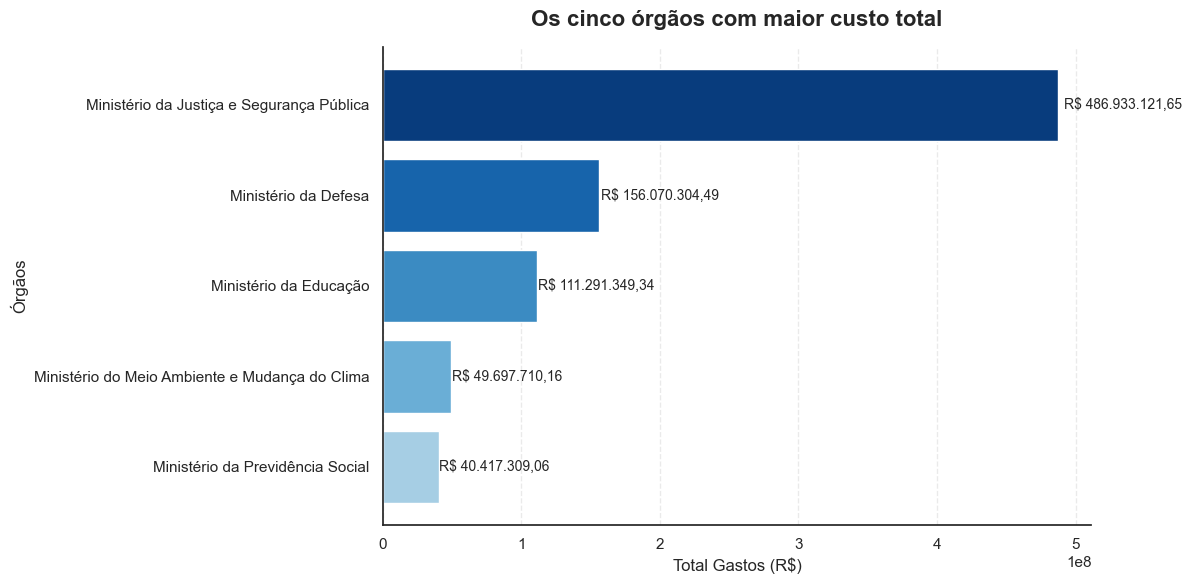

In [240]:
# ==============================================================
#PERGUNTA 1
# Os cinco órgãos com maior custo total
# ==============================================================
print("\n--- 1. Top 5 Órgãos com Maior Custo Total ---")
sql_1 = """
SELECT 
    nome_orgao_superior, 
    gasto_total
FROM gold_gastos_orgao
ORDER BY gasto_total DESC
LIMIT 5;
"""
df_1 = consultar(sql_1)
display(df_1)

# ==============================================================
# Gráfico - Os cinco órgãos com maior custo total
# ==============================================================

# Ordena do menor para o maior apenas para melhor visualização
df_grafico = df_1.sort_values("gasto_total", ascending=True)

# Cores em degradê (mais escuro = maior valor)
cores = plt.cm.Blues(np.linspace(0.35, 0.95, len(df_grafico)))

fig, ax = plt.subplots(figsize=(12,6))

barras = ax.barh(
    df_grafico["nome_orgao_superior"],
    df_grafico["gasto_total"],
    color=cores
)

# Adiciona os valores ao final das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura + largura*0.01,
        barra.get_y() + barra.get_height()/2,
        f'R$ {largura:,.2f}'.replace(",", "X").replace(".", ",").replace("X", "."),
        va='center',
        fontsize=10
    )

# Título e rótulos
ax.set_title(
    "Os cinco órgãos com maior custo total",
    fontsize=16,
    weight='bold',
    pad=15
)

ax.set_xlabel("Total Gastos (R$)", fontsize=12)
ax.set_ylabel("Órgãos", fontsize=12)

# Grade no eixo X
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Remove bordas superiores e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Salva o gráfico na pasta imagens
plt.savefig(
    PASTA_IMAGENS / "pergunta1_5órgãos_com_maior_custo",
    dpi=300,
    bbox_inches="tight")

plt.tight_layout()
plt.show()



In [241]:
# ==============================================================
# PERGUNTA 2
# Os três destinos com maior custo médio por viagem.
# ==============================================================
print("\n--- Pergunta 2: Os 3 destinos com maior custo médio por viagem ---")

sql_q2 = """
SELECT
    destino_cidade,
    destino_uf,
    SUM(total_viagens) AS qtd_viagens,
    ROUND(AVG(custo_medio), 2) AS custo_medio
FROM gold_destinos
GROUP BY destino_cidade, destino_uf
HAVING SUM(total_viagens) >= 5
ORDER BY custo_medio DESC
LIMIT 3;
"""
df_q2 = consultar(sql_q2)

display(df_q2)


--- Pergunta 2: Os 3 destinos com maior custo médio por viagem ---


,destino_cidade,destino_uf,qtd_viagens,custo_medio
0,Sananduva,Rio Grande do Sul,118,108309.30
1,Monte Negro,Rondônia,102,104979.28
2,Nonoai,Rio Grande do Sul,148,99278.92


In [242]:
# ==============================================================
# PERGUNTA 3
# A viagem de maior duração e seu custo total.
# ==============================================================
print("\n--- 3. Viagem de Maior Duração e seu Custo ---")
sql_3 = """
SELECT 
    id_viagem, nome_viajante, nome_orgao_superior, destinos,
    (data_fim - data_inicio) AS duracao_dias,
    valor_total
FROM silver_viagem
WHERE data_fim IS NOT NULL AND data_inicio IS NOT NULL
ORDER BY duracao_dias DESC
LIMIT 3;
"""
df_3 = consultar(sql_3)
display(df_3)





--- 3. Viagem de Maior Duração e seu Custo ---


,id_viagem,nome_viajante,nome_orgao_superior,destinos,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,Mogi Mirim/SP,383,0.00
1,0000000000020793594,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,378,120650.00
2,0000000000020793492,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,369,113382.50



--- 4. Tipo de Pagamento com Maior Valor Médio ---


,tipo_pagamento,num_pagamentos,valor_medio,valor_total
0,DIÁRIAS,401463,2078.28,834352643.52
1,PASSAGEM,188985,1878.34,354978915.13
2,Serviço correlato: seguro,4894,447.51,2190136.71
3,RESTITUIÇÃO,11574,245.70,2843762.01


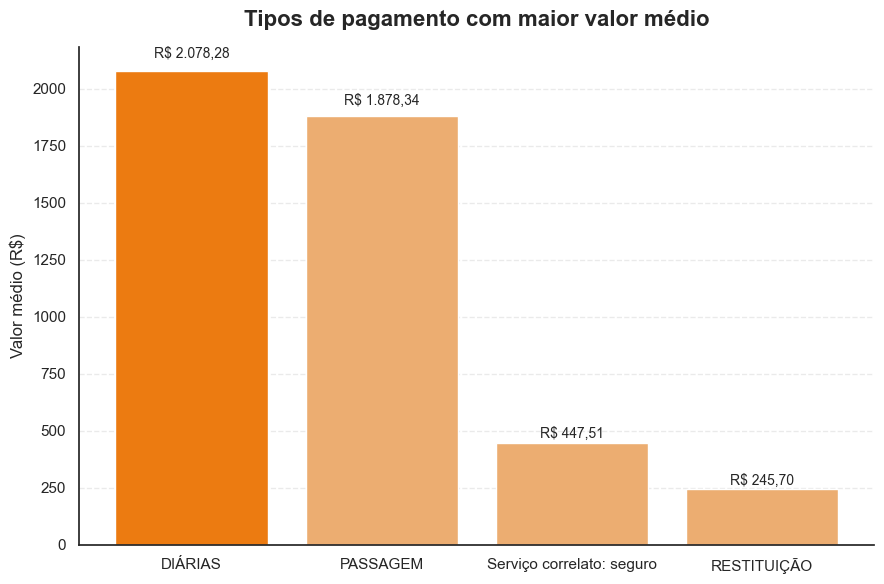

In [249]:
# ==============================================================
# PERGUNTA 4
# O tipo de pagamento com maior valor médio.
# ==============================================================
print("\n--- 4. Tipo de Pagamento com Maior Valor Médio ---")
sql_4 = """
    SELECT tipo_pagamento,
           count(*) AS num_pagamentos,
           round(avg(valor), 2) AS valor_medio,
           round(sum(valor), 2) AS valor_total
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
    LIMIT 5;
"""

df_4 = consultar(sql_4)
display(df_4)

# ==============================================================
# Gráfico - Tipos de pagamento com maior valor médio
# ==============================================================

# Cores: primeiro (maior valor) em azul escuro, demais em azul claro
cores = ["#EC7B11"] + ["#ECAD71"] * (len(df_4) - 1)

fig, ax = plt.subplots(figsize=(9,6))

barras = ax.bar(
    df_4["tipo_pagamento"],
    df_4["valor_medio"],
    color=cores
)

# Adiciona o valor acima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + altura*0.02,
        f'R$ {altura:,.2f}'.replace(",", "X").replace(".", ",").replace("X", "."),
        ha='center',
        va='bottom',
        fontsize=10
    )

# Título e rótulos
ax.set_title(
    "Tipos de pagamento com maior valor médio",
    fontsize=16,
    weight='bold',
    pad=15
)

#ax.set_xlabel("Tipo de pagamento", fontsize=12)
ax.set_ylabel("Valor médio (R$)", fontsize=12)

# Rotaciona os rótulos caso sejam longos
#plt.xticks(rotation=20, ha='right')

# Grade horizontal
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Salva o gráfico na pasta imagens
plt.savefig(
    PASTA_IMAGENS / "pergunta4_Tipos_de_pagamento_com _maior _valor",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


--- 5. Meio de Transporte Mais Utilizado ---


,meio_transporte,quantidade_utilizacao
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846


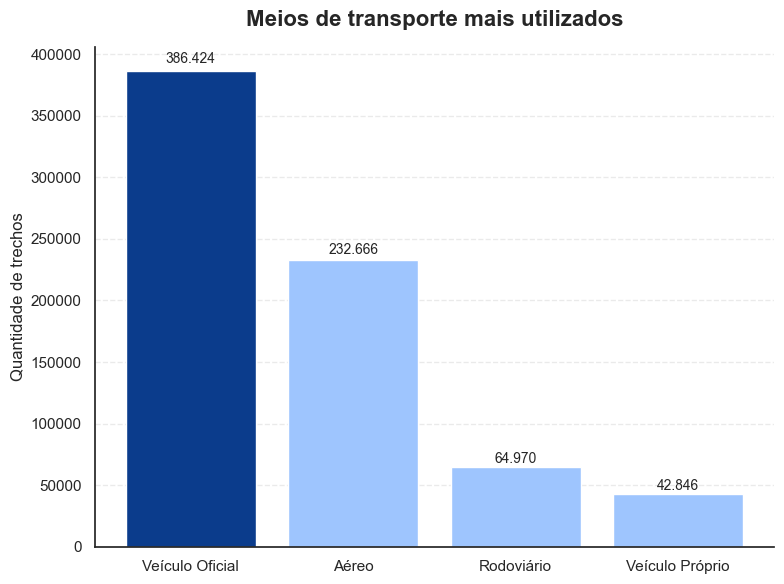

In [244]:
# ==============================================================
# PERGUNTA 5
# O meio de transporte mais utilizado.
# ==============================================================
print("\n--- 5. Meio de Transporte Mais Utilizado ---")
sql_5 = """
SELECT 
    meio_transporte, 
    COUNT(*) AS quantidade_utilizacao
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade_utilizacao DESC
LIMIT 4;
"""
df_5 = consultar(sql_5)
display(df_5)

# ==============================================================
# Gráfico - Meios de transporte mais utilizados
# ==============================================================

# Cores: maior valor em azul escuro, demais em azul claro
cores = ['#0B3C8C'] + ['#9EC5FE'] * (len(df_5) - 1)

fig, ax = plt.subplots(figsize=(8,6))

barras = ax.bar(
    df_5["meio_transporte"],
    df_5["quantidade_utilizacao"],
    color=cores
)

# Adiciona os valores acima das barras
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + altura*0.01,
        f'{int(altura):,}'.replace(",", "."),
        ha='center',
        va='bottom',
        fontsize=10
    )

# Título e rótulos
ax.set_title(
    "Meios de transporte mais utilizados",
    fontsize=16,
    weight='bold',
    pad=15
)

ax.set_ylabel("Quantidade de trechos", fontsize=12)


# Grade horizontal
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Salva o gráfico na pasta imagens
plt.savefig(
    PASTA_IMAGENS / "pergunta5_meios_transporte.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [245]:
# ==============================================================
# PERGUNTA 6
# A UF de destino mais frequente.
# ==============================================================
# 6. A UF de destino mais frequente
print("\n--- 6. UF de Destino Mais Frequente ---")
sql_6 = """
SELECT
    destino_uf,
    SUM(total_viagens) AS total_viagens
FROM gold_destinos
WHERE destino_uf IS NOT NULL
  AND destino_uf <> ''
GROUP BY destino_uf
ORDER BY total_viagens DESC
LIMIT 5;
"""
df_6 = consultar(sql_6)
display(df_6)


--- 6. UF de Destino Mais Frequente ---


,destino_uf,total_viagens
0,São Paulo,79684
1,Distrito Federal,75449
2,Minas Gerais,49316
3,Rio de Janeiro,43058
4,Paraná,38422
